# Determining Wine Quality using Machine Learning

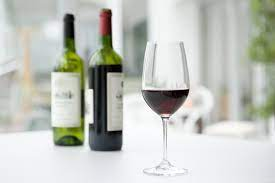

In this Notebook we will be using Machine Learning to determine the quality of Wine with the help of factors like the chemical composition of the vine the contenct of sulpher, alchohol and the quality of the wine.

### Time Line for the Project:
- Importing libraries
- Data Analysis
- Data Preprocessing
- Prediction using KNN
- Classification using SVM

#### Importing Libraries

In [1]:
import numpy as np
import pandas as pd  ##  data analysis
import matplotlib.pyplot as plt
import seaborn as sns  ## visualisation
%matplotlib inline

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler     ## preprocessing 

from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score    ### evaluation

In [2]:
df= pd.read_csv('/kaggle/input/datasets/willianoliveiragibin/modeling-wine/winequality-white new.csv')

In [3]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,quality,alcohol
0,7.0,0.27,0.36,20.7,45.00,45.0,170.0,1.001,3.00,0.45,6,"R$ 45.512,00"
1,6.3,0.30,0.34,1.6,49.00,14.0,132.0,994.000,3.30,0.49,6,"R$ 45.421,00"
2,8.1,0.28,0.40,6.9,0.05,30.0,97.0,9.951,3.26,0.44,6,"R$ 45.301,00"
3,7.2,0.23,0.32,8.5,58.00,47.0,186.0,9.956,3.19,0.40,6,"R$ 45.544,00"
4,7.2,0.23,0.32,8.5,58.00,47.0,186.0,9.956,3.19,0.40,6,"R$ 45.544,00"


In [4]:
df["alcohol"] = (
    df["alcohol"]
    .str.replace("R%","",regex=False)
    .str.replace(".","",regex=False)
    .str.replace(",",".",regex=False)
    .str.strip()
)
df["alcohol"] = pd.to_numeric(df["alcohol"],errors="coerce")

In [5]:
df['quality'].value_counts()

quality
6    2198
5    1457
7     880
8     175
4     163
3      20
9       5
Name: count, dtype: int64

### Data Analysis

In [6]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,quality,alcohol
count,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,31.000000
mean,6.854788,11.216659,0.334192,6.391415,40.608069,35.308085,138.360657,113.540098,3.188267,0.489847,5.877909,1105.516129
std,0.843868,67.987301,0.121020,5.072058,24.967489,17.007137,42.498065,232.603169,0.151001,0.114126,0.885639,214.849385
min,3.800000,0.080000,0.000000,0.600000,0.020000,2.000000,9.000000,0.990000,2.720000,0.220000,3.000000,80.000000
25%,6.300000,0.210000,0.270000,1.700000,33.000000,23.000000,108.000000,9.943000,3.090000,0.410000,5.000000,1055.000000
50%,6.800000,0.270000,0.320000,5.200000,41.000000,34.000000,134.000000,98.948500,3.180000,0.470000,6.000000,1145.000000
75%,7.300000,0.330000,0.390000,9.900000,48.000000,46.000000,167.000000,99.418000,3.280000,0.550000,6.000000,1194.500000
max,14.200000,965.000000,1.660000,65.800000,346.000000,289.000000,440.000000,999.000000,3.820000,1.080000,9.000000,1355.000000


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4898 entries, 0 to 4897
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         4898 non-null   float64
 1   volatile acidity      4898 non-null   float64
 2   citric acid           4898 non-null   float64
 3   residual sugar        4898 non-null   float64
 4   chlorides             4898 non-null   float64
 5   free sulfur dioxide   4898 non-null   float64
 6   total sulfur dioxide  4898 non-null   float64
 7   density               4898 non-null   float64
 8   pH                    4898 non-null   float64
 9   sulphates             4898 non-null   float64
 10  quality               4898 non-null   int64  
 11  alcohol               31 non-null     float64
dtypes: float64(11), int64(1)
memory usage: 459.3 KB


In [8]:
df.isnull().sum()  ## checking null values

fixed acidity              0
volatile acidity           0
citric acid                0
residual sugar             0
chlorides                  0
free sulfur dioxide        0
total sulfur dioxide       0
density                    0
pH                         0
sulphates                  0
quality                    0
alcohol                 4867
dtype: int64

In [9]:
df.shape

(4898, 12)

Plotting Histograms

In [10]:
df.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'quality', 'alcohol'],
      dtype='object')

In [11]:
cols= ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality']

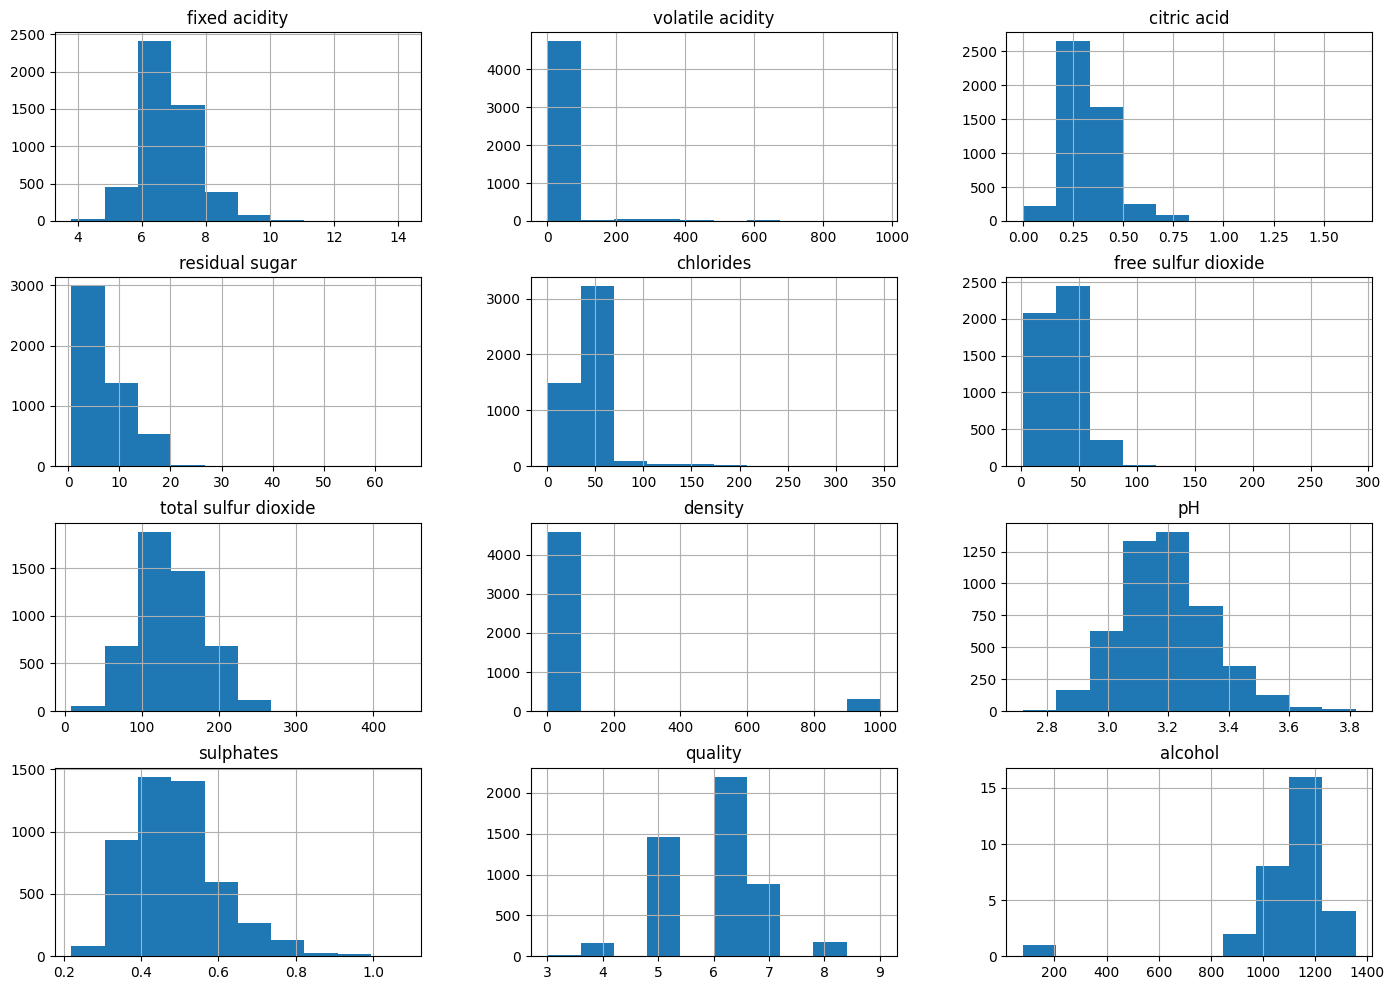

In [12]:
df.hist(figsize=(17,12))
plt.show()

PLotting Box Plots

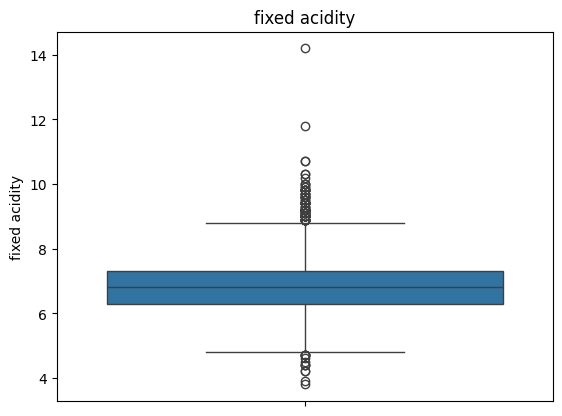

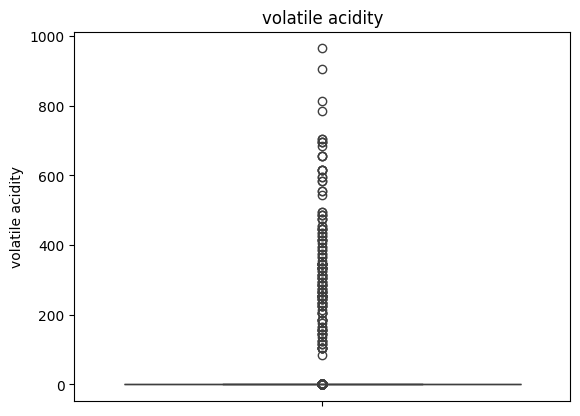

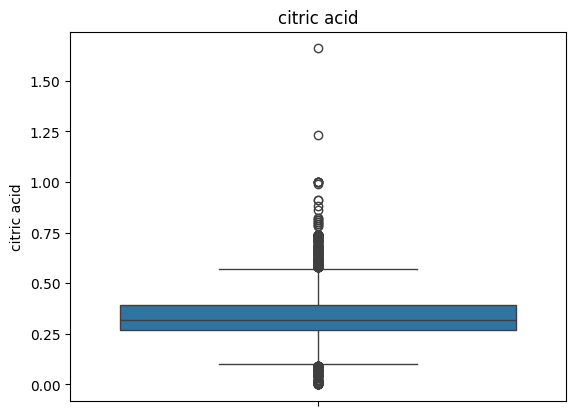

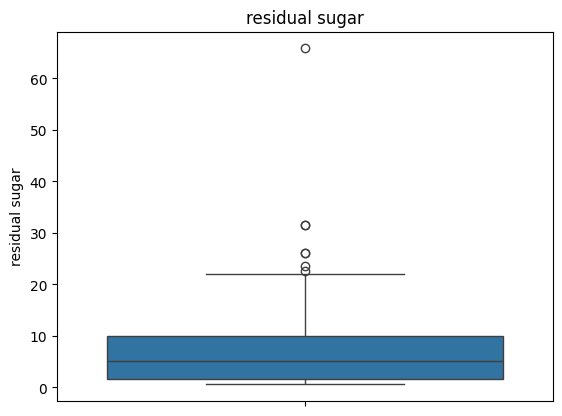

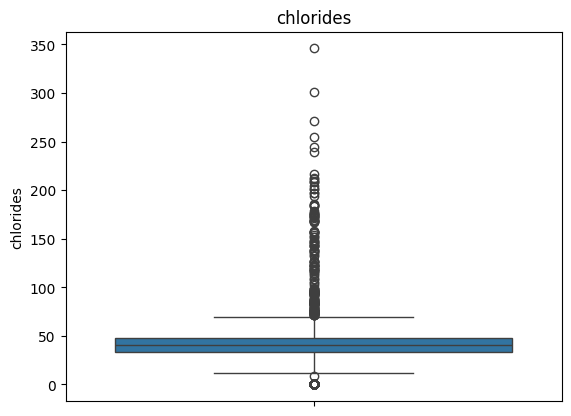

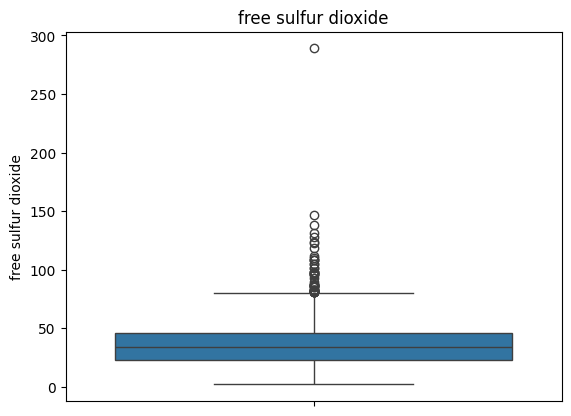

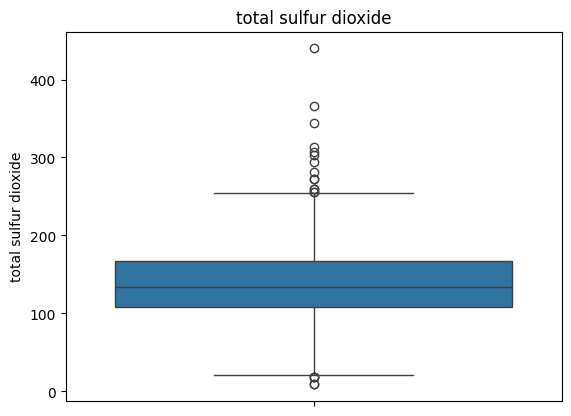

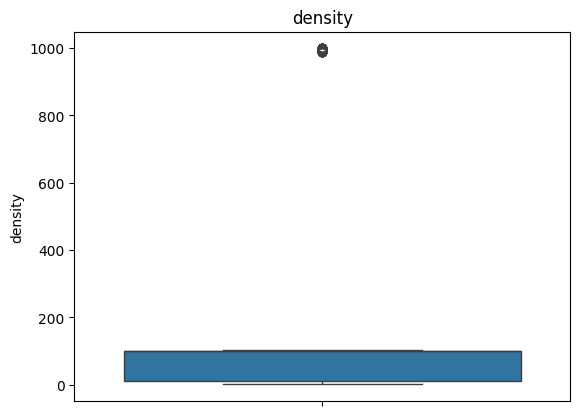

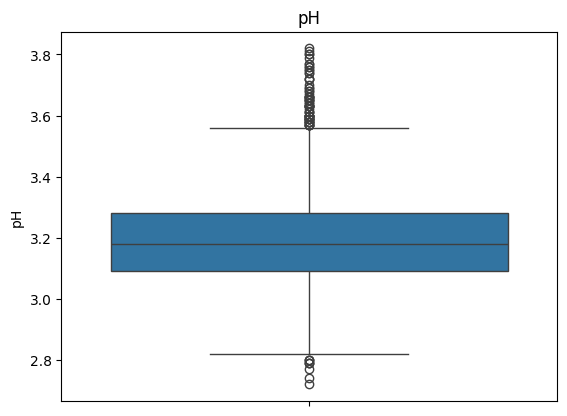

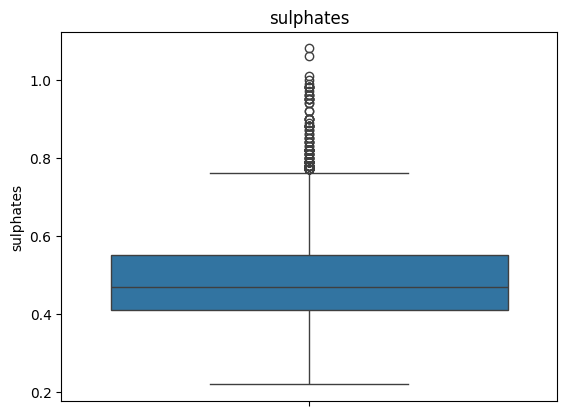

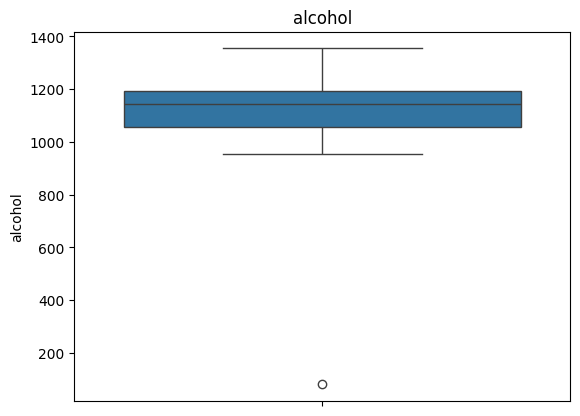

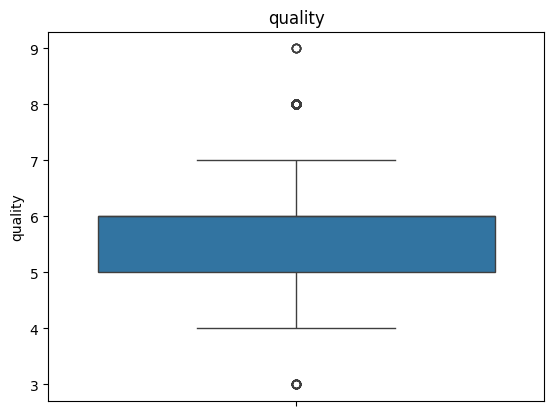

In [13]:
for col in cols:
    plt.figure()
    sns.boxplot(df[col])
    plt.title(col)

Plotting scatter plots

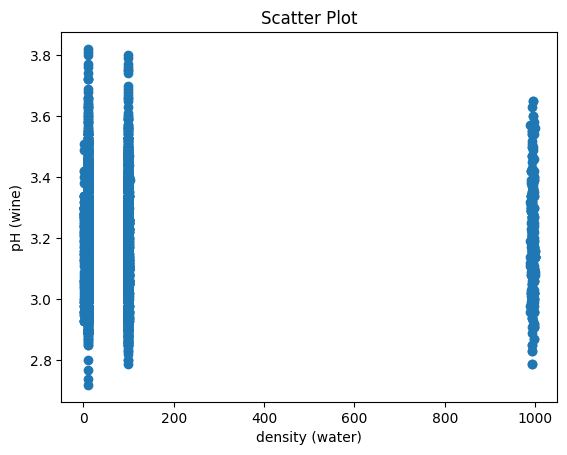

In [14]:
d = df["density"]
ph = df["pH"]

plt.scatter(d, ph)
plt.title("Scatter Plot")
plt.xlabel("density (water)")
plt.ylabel("pH (wine)")
plt.show()

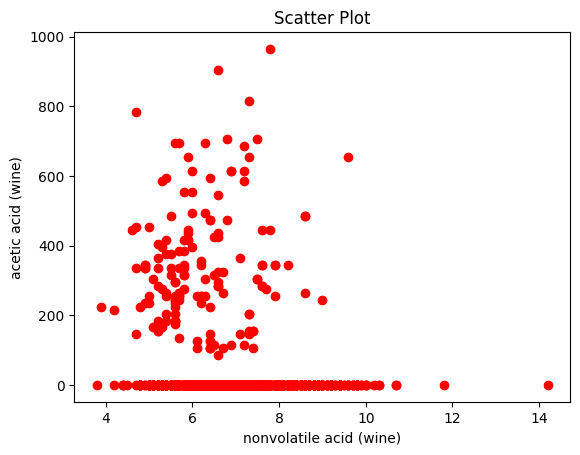

In [15]:
fa = df["fixed acidity"]
va = df["volatile acidity"]

plt.scatter(fa, va,color = 'red')
plt.title("Scatter Plot")
plt.xlabel("nonvolatile acid (wine)")
plt.ylabel("acetic acid (wine)")
plt.show()

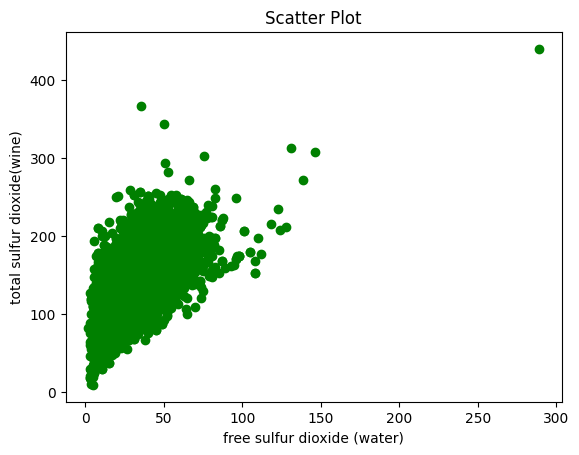

In [16]:
fsd = df["free sulfur dioxide"]
tsd = df["total sulfur dioxide"]

plt.scatter(fsd, tsd,color = 'green')
plt.title("Scatter Plot")
plt.xlabel("free sulfur dioxide (water)")
plt.ylabel("total sulfur dioxide(wine)")
plt.show()

<Axes: >

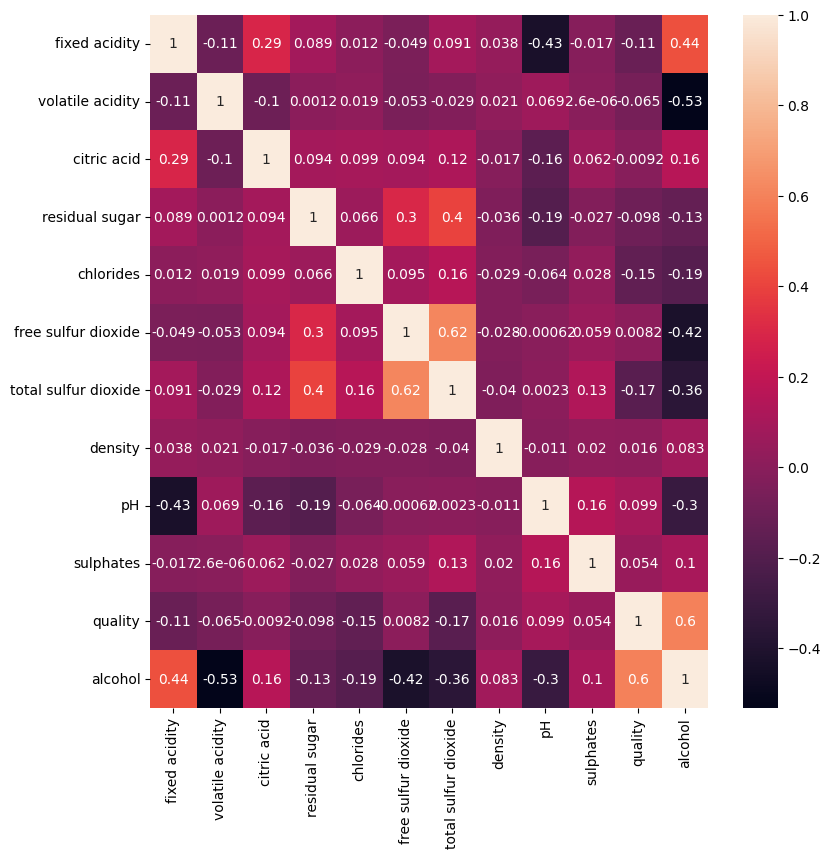

In [17]:
plt.figure(figsize=(9,9))
sns.heatmap(df.corr(numeric_only = True),annot=True)

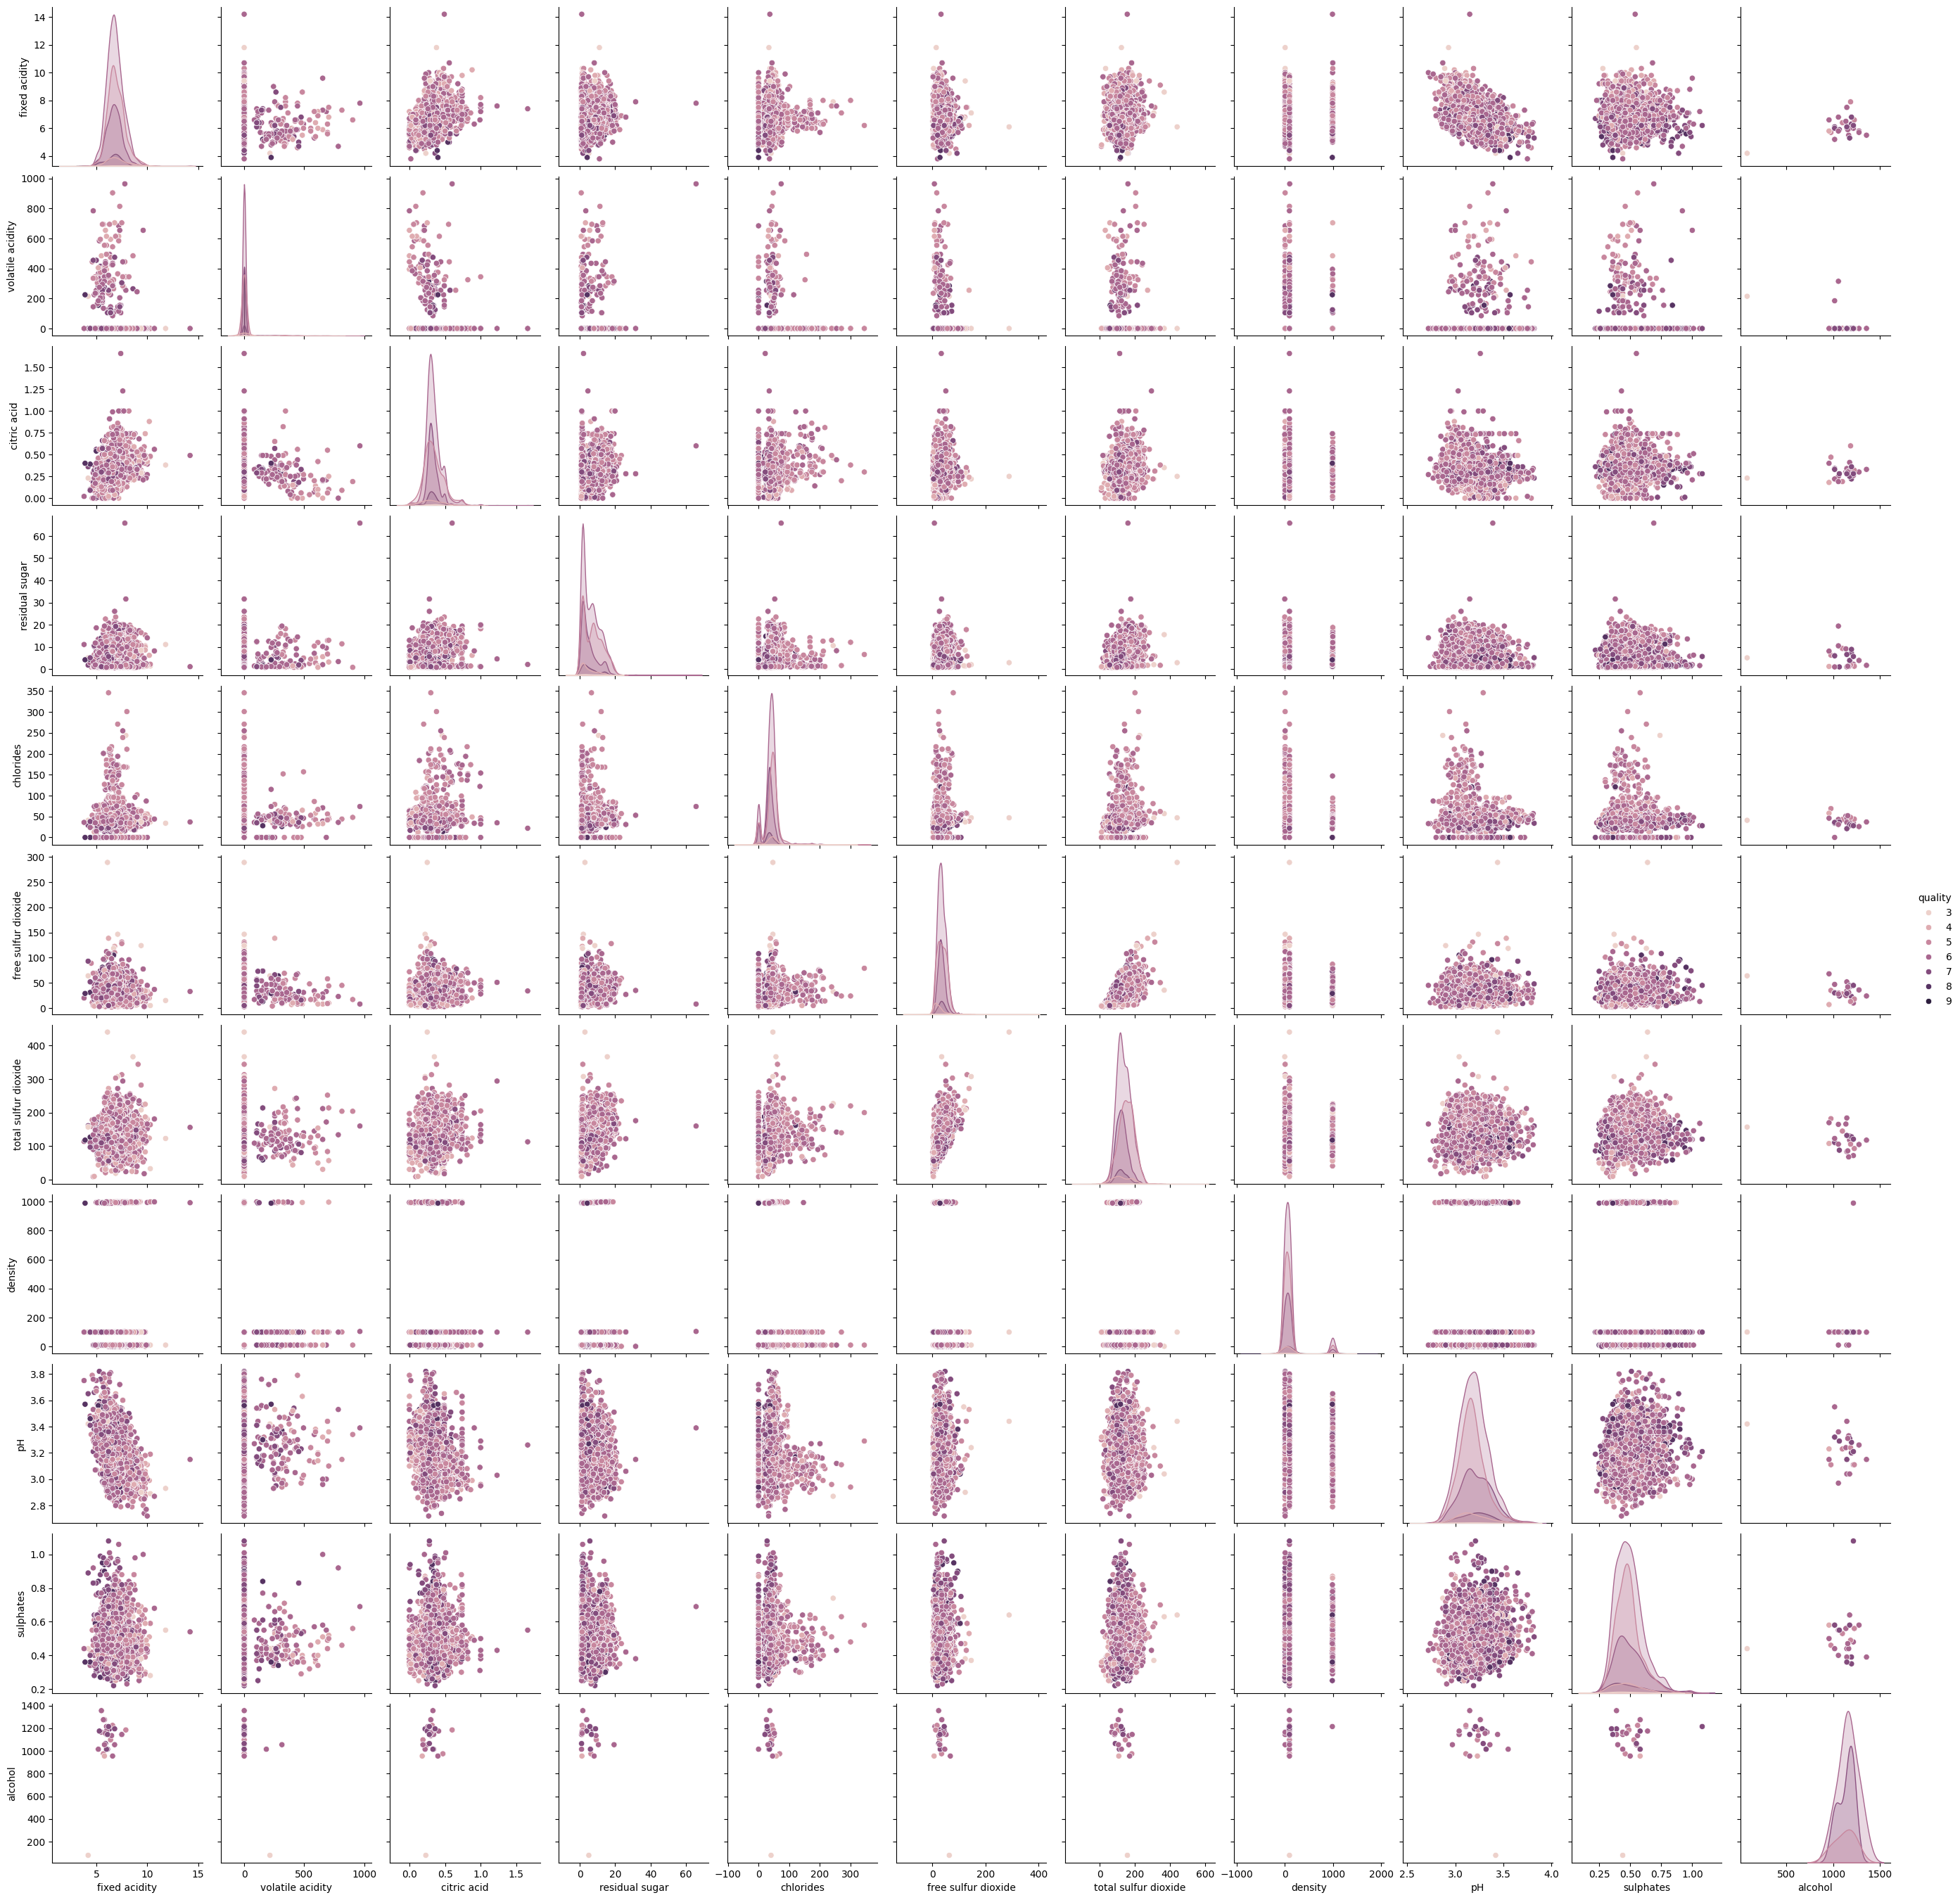

In [18]:
sns.pairplot(df,hue='quality')

Let us see the range of quality of wive

In [19]:
df['quality'].value_counts()

quality
6    2198
5    1457
7     880
8     175
4     163
3      20
9       5
Name: count, dtype: int64

(array([  20.,  163.,    0., 1457.,    0., 2198.,  880.,    0.,  175.,
           5.]),
 array([3. , 3.6, 4.2, 4.8, 5.4, 6. , 6.6, 7.2, 7.8, 8.4, 9. ]),
 <BarContainer object of 10 artists>)

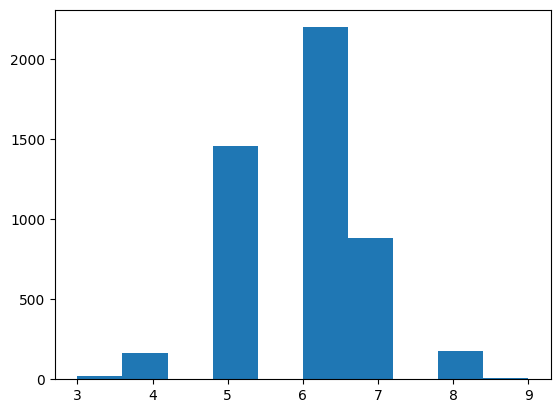

In [20]:
plt.hist(df['quality'])

#### Data Preprocessing

In [21]:
cols= ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol']

x = df[cols] ## independent var
y = df['quality']  ## dependent var

Splitting the data

In [22]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.20 , random_state=42,shuffle=True)

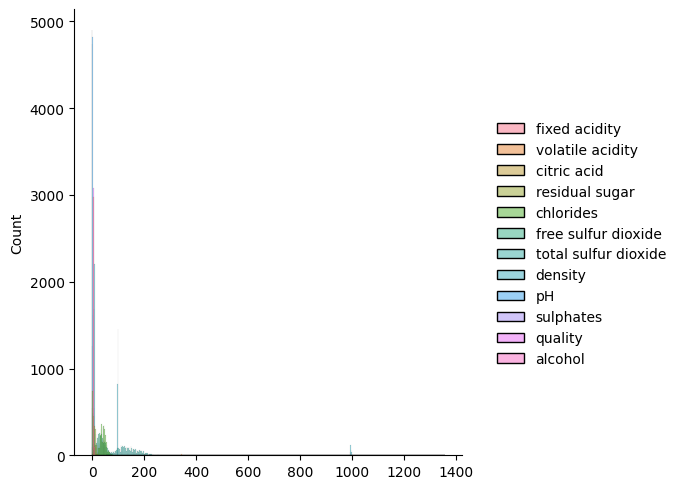

In [23]:
sns.displot(df)

In [24]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy="median")
x_train = imputer.fit_transform(x_train)
x_test = imputer.transform(x_test)

Scaling the data using Standard Scaler

In [25]:
from sklearn.preprocessing import StandardScaler
ss= StandardScaler()

In [26]:
x_train = ss.fit_transform(x_train)
x_test = ss.fit_transform(x_test)

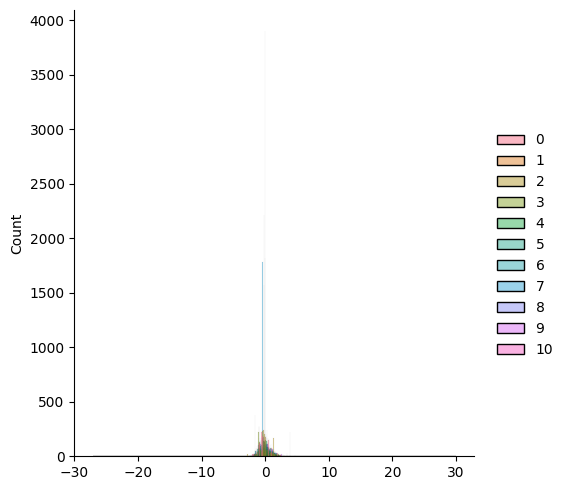

In [27]:
sns.displot(x_train)

In [28]:
x_test.shape

(980, 11)

### Method 1 :
### Prediction usign K Nearest Neighbour algorithm

In [29]:
from sklearn.neighbors import KNeighborsClassifier

In [30]:
knn = KNeighborsClassifier(n_neighbors=9)
knn.fit(x_train,y_train)

KNeighborsClassifier(n_neighbors=9)

In [31]:
pred=knn.predict(x_test)
pred

array([5, 6, 6, 5, 7, 6, 5, 6, 5, 5, 7, 7, 6, 5, 5, 6, 5, 6, 6, 6, 5, 6,
       5, 5, 6, 5, 5, 6, 5, 5, 5, 5, 6, 6, 5, 7, 6, 5, 5, 6, 5, 6, 7, 6,
       6, 6, 6, 5, 5, 5, 6, 5, 5, 7, 7, 5, 6, 6, 6, 6, 6, 6, 6, 6, 6, 7,
       6, 5, 6, 6, 5, 6, 6, 5, 6, 6, 6, 6, 7, 6, 6, 6, 6, 6, 6, 6, 5, 7,
       6, 6, 7, 5, 6, 6, 6, 7, 6, 6, 5, 6, 5, 5, 8, 6, 6, 6, 6, 7, 6, 6,
       5, 6, 6, 7, 6, 7, 6, 6, 5, 8, 6, 7, 6, 5, 5, 6, 6, 6, 7, 5, 5, 5,
       5, 6, 5, 5, 6, 6, 6, 5, 6, 6, 5, 5, 7, 5, 5, 6, 5, 6, 6, 6, 6, 6,
       7, 5, 7, 6, 6, 5, 5, 5, 5, 5, 5, 6, 5, 6, 5, 6, 6, 6, 6, 5, 7, 6,
       5, 5, 7, 6, 6, 5, 5, 6, 6, 6, 6, 6, 6, 6, 6, 7, 6, 6, 5, 5, 7, 7,
       6, 6, 7, 5, 6, 5, 5, 7, 7, 7, 5, 6, 5, 6, 6, 6, 6, 5, 6, 6, 6, 6,
       6, 6, 5, 6, 6, 5, 6, 7, 6, 5, 6, 5, 6, 6, 6, 7, 6, 7, 6, 7, 6, 6,
       6, 6, 7, 6, 5, 5, 6, 6, 5, 6, 6, 5, 6, 6, 6, 6, 6, 5, 6, 6, 5, 6,
       6, 6, 5, 5, 6, 6, 6, 6, 6, 6, 6, 5, 7, 6, 6, 6, 6, 6, 7, 6, 7, 6,
       7, 6, 5, 6, 6, 6, 6, 6, 6, 6, 5, 6, 5, 6, 6,

In [32]:
y_test

4656    7
3659    8
907     8
4352    5
3271    7
       ..
3207    6
1539    6
964     6
168     5
3661    6
Name: quality, Length: 980, dtype: int64

In [33]:
matrix = confusion_matrix(y_test,pred)
matrix

array([[  1,   0,   2,   1,   0,   1],
       [  0,   0,  12,  12,   1,   0],
       [  0,   4, 151, 118,  17,   1],
       [  0,   0, 103, 284,  42,   3],
       [  0,   0,  20, 110,  60,   2],
       [  0,   0,   3,  19,  10,   3]])

Let us find out the accuracy

In [34]:
print('Accuracy using KNN is : ',100*accuracy_score(y_test,pred))

Accuracy using KNN is :  50.91836734693877


### Method 2 :
### Prediction using SVM Classifier

In this we will classify if the wine is good or bad so we will create a column which will state that if a wine quality is greater than 5 then it is a good quality wine else it is not

In [35]:
y=df['quality']>5
y  ## dependent var

0        True
1        True
2        True
3        True
4        True
        ...  
4893     True
4894    False
4895     True
4896     True
4897     True
Name: quality, Length: 4898, dtype: bool

In [36]:
y.value_counts()

quality
True     3258
False    1640
Name: count, dtype: int64

In [37]:
x=df.iloc[:,:-1]
x   ## independent var

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,quality
0,7.0,0.27,0.36,20.7,45.00,45.0,170.0,1.001,3.00,0.45,6
1,6.3,0.30,0.34,1.6,49.00,14.0,132.0,994.000,3.30,0.49,6
2,8.1,0.28,0.40,6.9,0.05,30.0,97.0,9.951,3.26,0.44,6
3,7.2,0.23,0.32,8.5,58.00,47.0,186.0,9.956,3.19,0.40,6
4,7.2,0.23,0.32,8.5,58.00,47.0,186.0,9.956,3.19,0.40,6
...,...,...,...,...,...,...,...,...,...,...,...
4893,6.2,0.21,0.29,1.6,39.00,24.0,92.0,99.114,3.27,0.50,6
4894,6.6,0.32,0.36,8.0,47.00,57.0,168.0,9.949,3.15,0.46,5
4895,6.5,0.24,0.19,1.2,41.00,30.0,111.0,99.254,2.99,0.46,6
4896,5.5,0.29,0.30,1.1,22.00,20.0,110.0,98.869,3.34,0.38,7


In [38]:
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=0,test_size=0.25) ##splitting the data

In [39]:
scaled_x_train=ss.fit_transform(x_train)

scaled_x_train

array([[-0.07184924, -0.15719852, -0.44478469, ...,  0.01257632,
        -0.69116914,  0.11919363],
       [ 2.10866059, -0.15913997,  0.72993119, ..., -0.51837586,
        -0.00283448,  1.26226983],
       [-1.52552246, -0.15809457,  0.31038981, ...,  0.67626656,
        -1.3795038 ,  0.11919363],
       ...,
       [ 1.26068454, -0.15719852, -0.44478469, ..., -0.25289977,
        -0.94929464,  0.11919363],
       [ 2.47207889, -0.15824392, -0.0252433 , ..., -0.38563781,
        -0.26095998,  0.11919363],
       [ 1.26068454, -0.15451035,  0.05866498, ..., -0.65111391,
         0.16924918, -1.02388258]])

In [40]:
scaled_x_test=ss.transform(x_test)

scaled_x_test

array([[ 0.53384793, -0.15734786,  0.14257325, ...,  0.34442144,
        -0.60512731, -1.02388258],
       [ 0.17042963, -0.1574972 , -0.61260124, ..., -0.38563781,
        -0.26095998,  0.11919363],
       [ 0.89726624, -0.16003603,  3.41499607, ..., -0.78385195,
        -0.77721097,  1.26226983],
       ...,
       [-1.16210415, -0.15913997, -0.44478469, ...,  1.40632581,
        -0.69116914,  0.11919363],
       [-1.04096472, -0.16003603, -1.36777574, ..., -0.91659   ,
         0.68550017,  0.11919363],
       [-0.19298868, -0.15406232, -0.52869296, ..., -0.18653075,
        -0.94929464, -2.16695878]])

In [41]:
x_test.shape

(1225, 11)

Performing Classification

In [42]:
from sklearn.svm import SVC

svc_clf = SVC(C=1.0, 
              kernel='rbf', 
              degree=3, 
              gamma='auto', 
              probability=False, 
              tol=0.001, cache_size=200, 
              verbose=False, max_iter=-1, 
              decision_function_shape='ovr', 
              random_state=None)

svc_clf.fit(scaled_x_train,y_train)

SVC(gamma='auto')

In [43]:
pred1=svc_clf.predict(scaled_x_test)

Checing Accuracy

In [44]:
print(confusion_matrix(y_test,pred1))

[[441   0]
 [  4 780]]


In [45]:
print("Accuracy using SVM is : ",100*accuracy_score(y_test,pred1))

Accuracy using SVM is :  99.67346938775509


Plotting a confusion matrix

In [46]:
matrix= confusion_matrix(y_test,pred1)

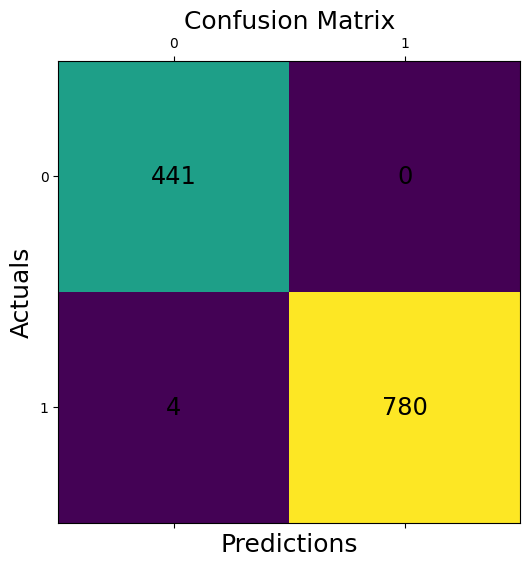

In [47]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.matshow(matrix )
for i in range(matrix.shape[0]):
    for j in range(matrix.shape[1]):
        ax.text(x=j, y=i,s=matrix[i, j], va='center', ha='center', size='xx-large')
plt.xlabel('Predictions', fontsize=18)
plt.ylabel('Actuals', fontsize=18)
plt.title('Confusion Matrix', fontsize=18)
plt.show()